# Titanic Survival Analysis using Python

## PROBLEM STATEMENT
The objective of this project is to analyze the Titanic dataset to identify key factors that influenced passenger survival. 
The analysis focuses on understanding how features such as gender, passenger class, age, and fare affected survival rates.

## IMPORT LIBRARIES

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## LOAD DATA

In [3]:
df = pd.read_csv("../data/titanic.csv")

## BASIC CHECK

In [4]:
df.shape

(1000, 9)

In [5]:
df.head()

,passengerId,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,1,0,1,male,44.8,4,1,29.70,S
1,2,1,3,male,38.6,1,0,41.58,S
2,3,1,3,female,39.6,3,3,94.58,S
3,4,0,3,male,10.9,2,3,62.99,S
4,5,0,3,male,47.0,0,3,84.32,C


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerId  1000 non-null   int64  
 1   survived     1000 non-null   int64  
 2   pclass       1000 non-null   int64  
 3   sex          1000 non-null   object 
 4   age          900 non-null    float64
 5   sibsp        1000 non-null   int64  
 6   parch        1000 non-null   int64  
 7   fare         1000 non-null   float64
 8   embarked     1000 non-null   object 
dtypes: float64(2), int64(5), object(2)
memory usage: 70.4+ KB


In [7]:
df.describe()

,passengerId,survived,pclass,age,sibsp,parch,fare
count,1000.000000,1000.000000,1000.000000,900.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,0.368000,2.327000,29.853333,1.942000,1.496000,52.571900
std,288.819436,0.482503,0.847815,14.098004,1.419384,1.119481,27.807056
min,1.000000,0.000000,1.000000,-11.900000,0.000000,0.000000,5.370000
25%,250.750000,0.000000,2.000000,19.800000,1.000000,1.000000,28.122500
50%,500.500000,0.000000,3.000000,29.500000,2.000000,1.000000,52.720000
75%,750.250000,1.000000,3.000000,39.500000,3.000000,3.000000,77.112500
max,1000.000000,1.000000,3.000000,85.000000,4.000000,3.000000,99.950000


The dataset contains passenger details such as age, gender, ticket class, fare, and survival status. 
Some columns contain missing values which need to be handled before analysis.

In [8]:
df.isnull().sum()

passengerId      0
survived         0
pclass           0
sex              0
age            100
sibsp            0
parch            0
fare             0
embarked         0
dtype: int64

## HANDLE MISSING VALUES

In [9]:
df["age"].fillna(df["age"].median(), inplace=True)
df["fare"].fillna(df["fare"].median(), inplace=True)

# Drop columns with too many missing values (if present)
if "deck" in df.columns:
    df.drop(columns=["deck"], inplace=True)

/var/folders/f4/5lg5p1t110g04bx8cbs6m7k40000gn/T/ipykernel_7095/1707485773.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(), inplace=True)
/var/folders/f4/5lg5p1t110g04bx8cbs6m7k40000gn/T/ipykernel_7095/1707485773.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerId  1000 non-null   int64  
 1   survived     1000 non-null   int64  
 2   pclass       1000 non-null   int64  
 3   sex          1000 non-null   object 
 4   age          1000 non-null   float64
 5   sibsp        1000 non-null   int64  
 6   parch        1000 non-null   int64  
 7   fare         1000 non-null   float64
 8   embarked     1000 non-null   object 
dtypes: float64(2), int64(5), object(2)
memory usage: 70.4+ KB


Missing values in the age and fare columns were replaced with median values to avoid distortion caused by extreme values. 
Columns with excessive missing values were removed to maintain data reliability.

## SURVIVAL DISTRIBUTION

In [11]:
df["survived"].value_counts()

survived
0    632
1    368
Name: count, dtype: int64

The dataset shows the number of passengers who survived and those who did not survive.

## SURVIVAL BY GENDER

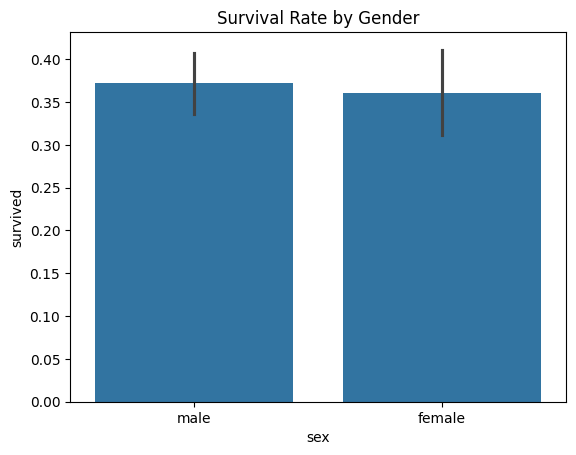

In [12]:
sns.barplot(x="sex", y="survived", data=df)
plt.title("Survival Rate by Gender")
plt.savefig("../outputs/charts/survival_gender.png")
plt.show()

Female passengers had a significantly higher survival rate compared to male passengers.

## SURVIVAL BY CLASS

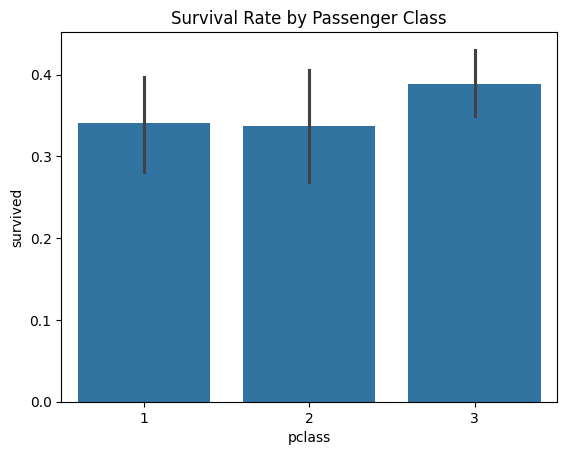

In [13]:
sns.barplot(x="pclass", y="survived", data=df)
plt.title("Survival Rate by Passenger Class")
plt.savefig("../outputs/charts/survival_class.png")
plt.show()

Passengers in higher classes had better chances of survival compared to those in lower classes.

## AGE DISTRIBUTION

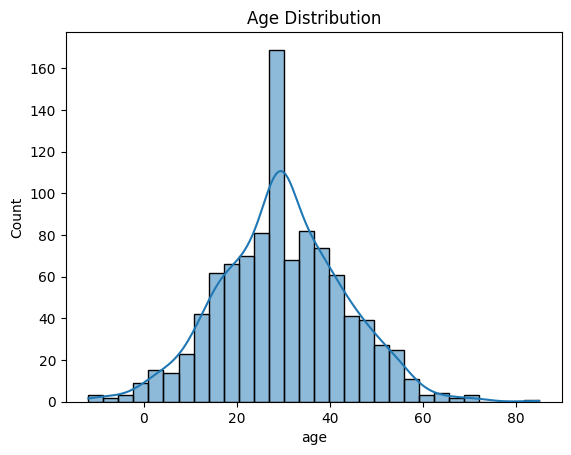

In [14]:
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.savefig("../outputs/charts/age_distribution.png")
plt.show()

Most passengers were between 20 and 40 years old, indicating a young to middle-aged population.

## CREATE NEW FEATURE

In [15]:
df["family_size"] = df["sibsp"] + df["parch"]

In [16]:
df.head()

,passengerId,survived,pclass,sex,age,sibsp,parch,fare,embarked,family_size
0,1,0,1,male,44.8,4,1,29.70,S,5
1,2,1,3,male,38.6,1,0,41.58,S,1
2,3,1,3,female,39.6,3,3,94.58,S,6
3,4,0,3,male,10.9,2,3,62.99,S,5
4,5,0,3,male,47.0,0,3,84.32,C,3


A new feature called family_size was created to analyze whether traveling with family influenced survival rates.

## FAMILY VS SURVIVAL

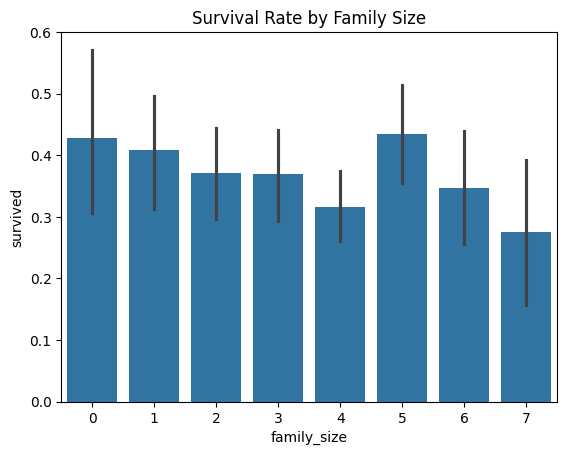

In [17]:
sns.barplot(x="family_size", y="survived", data=df)
plt.title("Survival Rate by Family Size")
plt.savefig("../outputs/charts/family_survival.png")
plt.show()

## Correlation Analysis

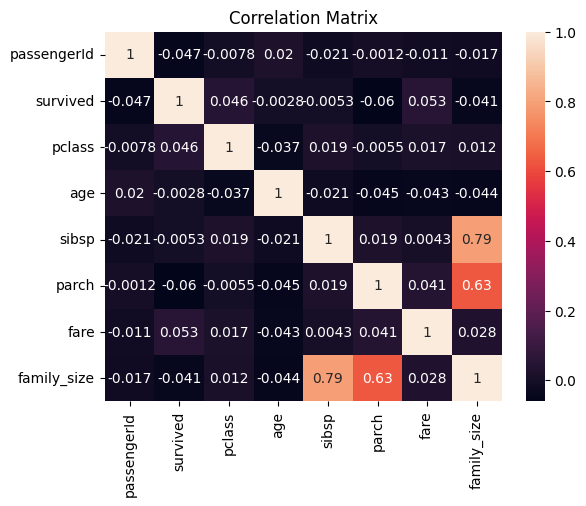

In [18]:
corr = df.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.savefig("../outputs/charts/correlation.png")
plt.show()

## ML Model 

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Select features
df_model = df[["survived", "pclass", "age", "fare"]].dropna()

X = df_model.drop("survived", axis=1)
y = df_model["survived"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Accuracy
accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.68


A logistic regression model was implemented to predict survival probability based on key features. 
The model provides a basic understanding of how different variables contribute to survival outcomes.

## Key Findings:

- Female passengers had a significantly higher survival rate than male passengers.
- Passengers in higher classes (1st class) had better survival chances.
- Fare showed a positive relationship with survival probability.
- Most passengers were young adults.
- Family size had an influence on survival, indicating group dynamics affected outcomes.